# 2. Multiple intervals, quality diagnostics, and summary plots
This independent example generates reproducible **synthetic** correlated signals
for six 30-minute periods at 20 Hz. No input files or earlier notebook outputs are
required. It deliberately adds a long missing-wind gap in one interval to show
how invalid spectra are retained in diagnostic tables and excluded from plots.
The artificial signals do not establish realistic turbulence spectra or field QC thresholds.

Install from the repository root with `pip install -e ".[notebooks]"`, launch
`jupyter notebook`, and run all cells. PNG/PDF and table outputs go to
`examples/outputs/multi_interval/`; rerunning replaces those files.

In [1]:
OUTPUT_NAME = "multi_interval"
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

# Works when Jupyter starts in the repository root or examples/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src" / "TaylorSwift").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from the TaylorSwift checkout.")
sys.path.insert(0, str(ROOT / "src"))
import TaylorSwift as tswift

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
OUTPUT = ROOT / "examples" / "outputs" / OUTPUT_NAME
OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"TaylorSwift {tswift.__version__}; outputs: {OUTPUT}")

def save_plot(fig, name):
    # Reserve a separate margin for shared spectral colorbars.
    colorbars = [ax for ax in fig.axes if ax.get_label() == "<colorbar>"]
    if colorbars and len(fig.axes) == 5:
        fig.subplots_adjust(right=0.86)
        colorbars[0].set_position([0.90, 0.15, 0.02, 0.70])
    for extension in ("png", "pdf"):
        fig.savefig(OUTPUT / f"{name}.{extension}", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


TaylorSwift 0.2.2; outputs: C:\Users\paulinkenbrandt\Documents\Github\TaylorSwift\examples\outputs\multi_interval


## Construct regularly sampled data
Wind is in m/s, sonic temperature in °C, CO₂ density in mg/m³, and H₂O density
in g/m³. A low-pass filtered random signal creates correlated fluctuations;
the heat coupling changes between intervals. Timestamp values are interpreted as UTC.

In [2]:
from scipy.signal import lfilter

rng = np.random.default_rng(20240910)
config = tswift.SiteConfig(sampling_freq=20.0, averaging_period=30.0,
                          z_measurement=3.0, z_canopy=0.3)
n = int(config.sampling_freq * config.averaging_period * 60)

def fluctuation():
    x = lfilter([1.0], [1.0, -0.92], rng.normal(size=n))
    return (x - x.mean()) / x.std()

blocks = []
for i, heat_coupling in enumerate([0.25, 0.18, 0.10, -0.08, -0.15, 0.20]):
    w = 0.35 * fluctuation()
    blocks.append(pd.DataFrame({
        "TIMESTAMP": pd.date_range(pd.Timestamp("2024-07-15 12:00") + pd.Timedelta(minutes=30*i),
                                   periods=n, freq="50ms"),
        "Ux": 4.0 + 0.2*i - 0.6*w + 0.5*fluctuation(),
        "Uy": 0.15 + 0.3*fluctuation(), "Uz": w,
        "T_SONIC": 24.0 + heat_coupling*w + 0.12*fluctuation(),
        "CO2_density": 750.0 - 1.5*w + 0.4*fluctuation(),
        "H2O_density": 12.0 + 0.3*w + 0.1*fluctuation(),
    }))
frame = pd.concat(blocks, ignore_index=True)
# Preserve timestamps: do not compress time by dropping missing samples.
gap_start = 4*n + 1000
frame.loc[gap_start:gap_start+39, "Uz"] = np.nan  # 2 s exceeds max_gap_seconds=1
display(frame.head())
print(f"{len(frame):,} samples across {len(blocks)} intervals")

,TIMESTAMP,Ux,Uy,Uz,T_SONIC,CO2_density,H2O_density
0,2024-07-15 12:00:00.000,4.238112,0.011464,-0.232593,23.933481,750.357880,11.962710
1,2024-07-15 12:00:00.050,4.035227,-0.122796,-0.185312,23.946624,750.148536,11.981195
2,2024-07-15 12:00:00.100,4.233034,-0.028427,-0.370193,23.939401,750.657849,11.787865
3,2024-07-15 12:00:00.150,4.395060,-0.078672,-0.408982,23.986968,750.689904,11.804656
4,2024-07-15 12:00:00.200,4.265985,-0.059837,-0.592807,23.905281,750.878205,11.748639


216,000 samples across 6 intervals


## Process all intervals and inspect why one is rejected
The processor skips blocks with fewer than 90% of the expected records. Here every
timestamp is present, so all six periods produce results; the long wind gap instead
produces empty spectra and a diagnostic status. Small eligible internal gaps can be
interpolated according to `SiteConfig`. Inspect gaps before processing real data.

In [3]:
results = tswift.run_qc(tswift.process_file(frame, config))
table = tswift.results_to_dataframe(results)
display(table.select("timestamp_start", "interval_status", "w_status", "ustar", "H", "ustar_filter"))
usable = [r for r in results if len(r.freq) and np.isfinite(r.zL)]
assert len(results) == 6 and len(usable) == 5
print(f"{len(usable)} intervals with spectra / {len(results)} processed")

timestamp_start,interval_status,w_status,ustar,H,ustar_filter
datetime[μs],str,str,f64,f64,bool
2024-07-15 12:00:00,"""ok""","""ok""",0.268964,37.046417,false
2024-07-15 12:30:00,"""ok""","""ok""",0.266675,27.20258,false
2024-07-15 13:00:00,"""ok""","""ok""",0.265478,14.21416,false
2024-07-15 13:30:00,"""ok""","""ok""",0.267572,-11.064279,false
2024-07-15 14:00:00,"""invalid_wind""","""gap_too_long""",NaN,NaN,null
2024-07-15 14:30:00,"""ok""","""ok""",0.270157,30.69113,false


5 intervals with spectra / 6 processed


## Plot the time series and retained spectra
The overview includes all periods so rejected data appear as gaps. Spectral plots
use intervals with available spectra and finite stability. This is an availability
selection, not a claim that each interval passes all scientific QC tests.
`ustar_filter=True` marks low friction velocity; slope diagnostics require interpretation.

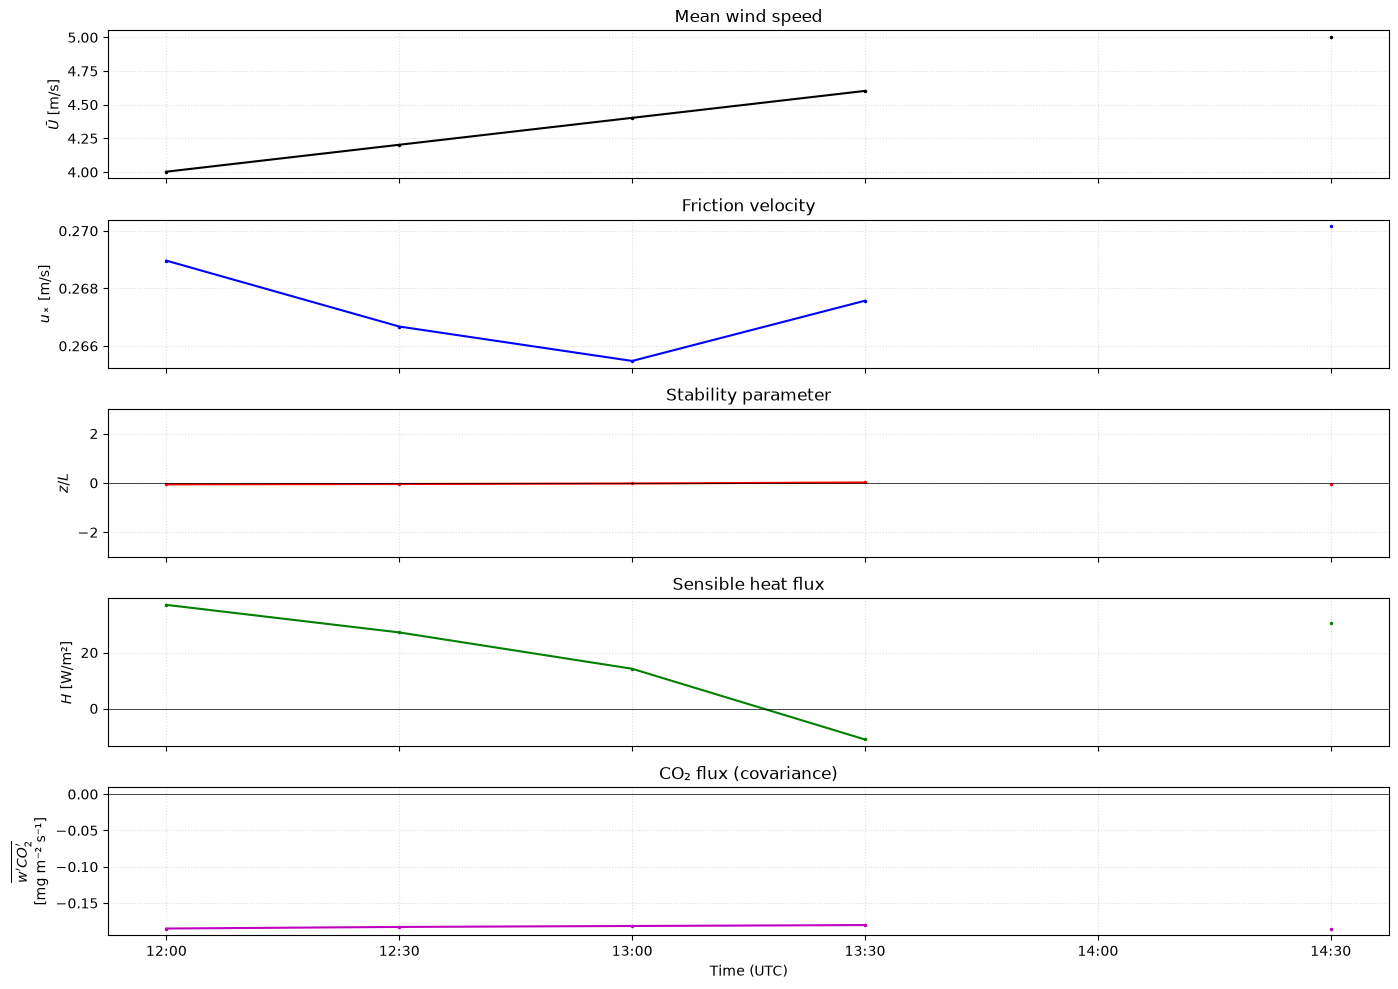

C:\Users\paulinkenbrandt\Documents\Github\TaylorSwift\src\TaylorSwift\plotting.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


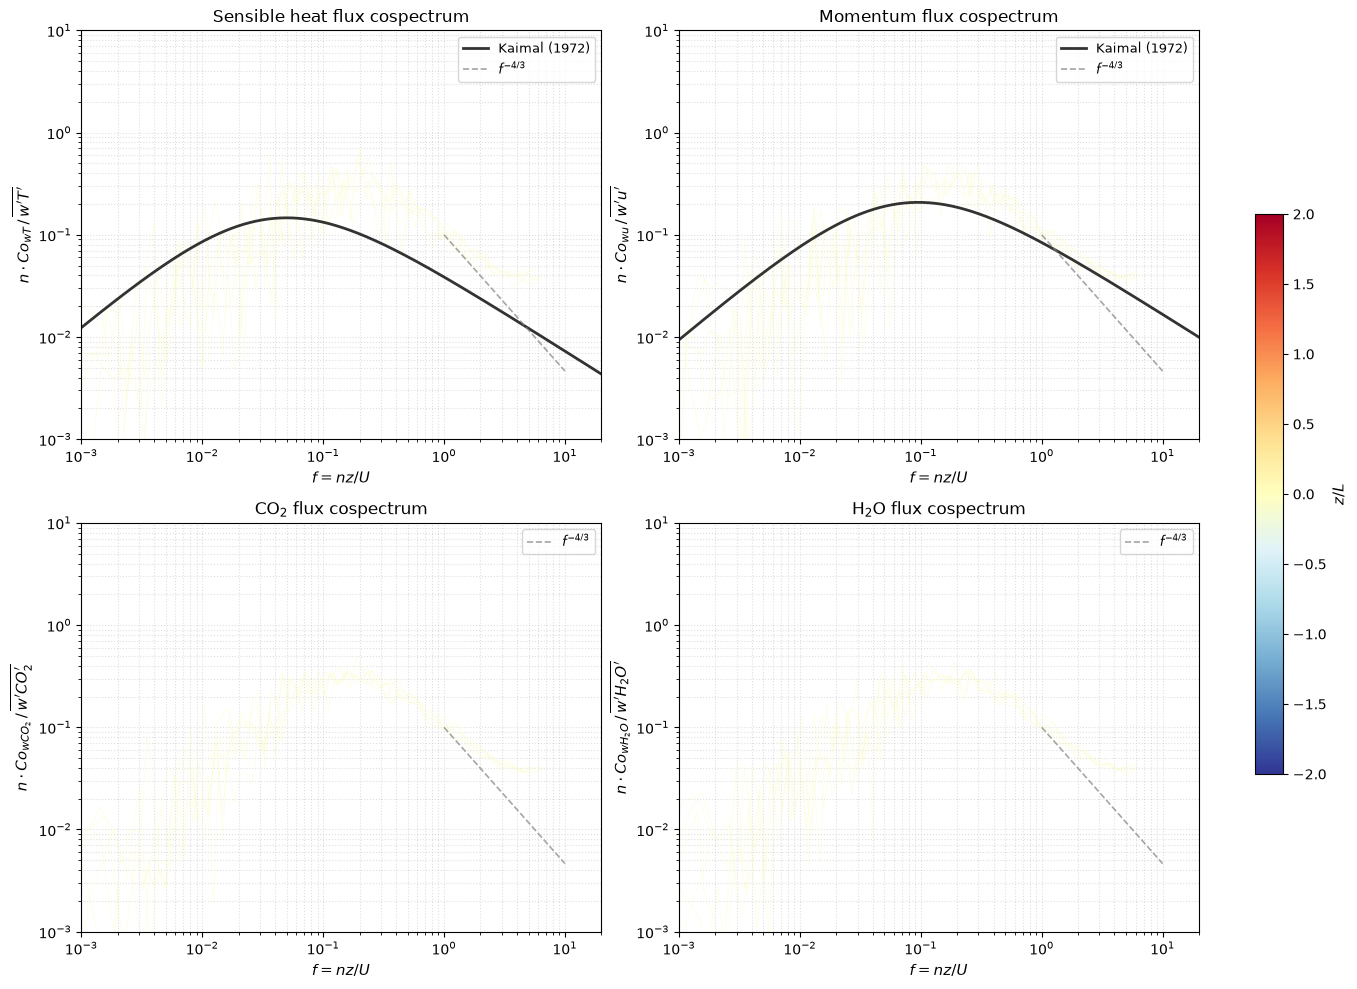

In [4]:
from TaylorSwift.plotting import plot_summary_timeseries
fig, axes = plot_summary_timeseries(results)
save_plot(fig, "summary_timeseries")
fig, axes = tswift.plot_cospectra(usable, stability_range=(-np.inf, np.inf))
save_plot(fig, "multi_interval_cospectra")

## Compare heat flux and stability by interval
Keep rejected intervals in the export. The heat-flux plot uses only available
spectra, with color showing stability. Positive and negative heat covariance were
intentionally included in the synthetic generator.

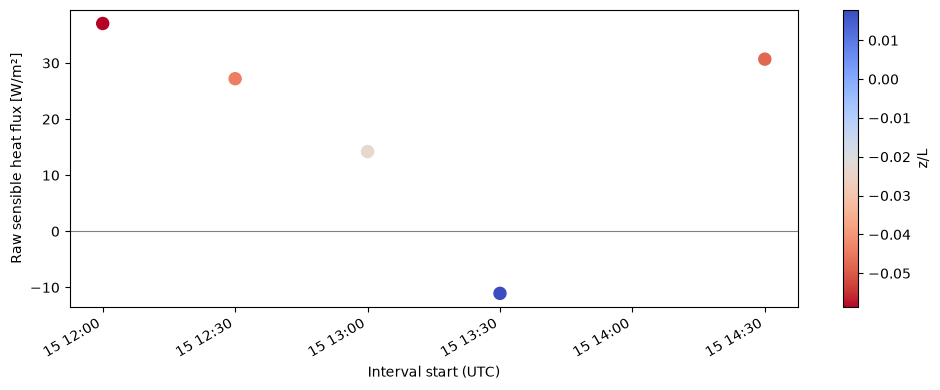

timestamp_start,freq,freq_nd,ncosp_wT
datetime[μs],f64,f64,f64
2024-07-15 12:00:00,0.000589,0.000412,0.001069
2024-07-15 12:00:00,0.001175,0.000822,0.000441
2024-07-15 12:00:00,0.001661,0.001162,-0.00035
2024-07-15 12:00:00,0.002347,0.001642,0.02008
2024-07-15 12:00:00,0.002634,0.001842,0.008265


['all_intervals_with_qc.csv',
 'all_intervals_with_qc.parquet',
 'available_spectra.parquet',
 'heat_flux_by_stability.pdf',
 'heat_flux_by_stability.png',
 'multi_interval_cospectra.pdf',
 'multi_interval_cospectra.png',
 'summary_timeseries.pdf',
 'summary_timeseries.png']

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
points = ax.scatter([r.timestamp_start for r in usable], [r.H for r in usable],
                    c=[r.zL for r in usable], cmap="coolwarm_r", s=75)
ax.axhline(0, color="0.5", linewidth=0.8)
ax.set(xlabel="Interval start (UTC)", ylabel="Raw sensible heat flux [W/m²]")
fig.colorbar(points, ax=ax, label="z/L")
fig.autofmt_xdate()
fig.tight_layout()
save_plot(fig, "heat_flux_by_stability")
tswift.results_to_csv(results, OUTPUT / "all_intervals_with_qc.csv")
tswift.results_to_parquet(results, OUTPUT / "all_intervals_with_qc.parquet")
spectra = tswift.spectra_to_dataframe(usable)
spectra.write_parquet(OUTPUT / "available_spectra.parquet")
display(spectra.select("timestamp_start", "freq", "freq_nd", "ncosp_wT").head())
display(sorted(p.name for p in OUTPUT.iterdir()))

## Adapt to your files
Replace the generator with `frame, metadata = tswift.read_toa5(path)` or use
`compile_toa5` for a directory (see the I/O guide). Set sampling frequency, averaging
period, column mappings, and units before processing. Check timestamp continuity
and instrument diagnostics, choose despiking and site-specific QC criteria, then
apply the corrections demonstrated in notebook 1. Preserve the full diagnostic
table alongside any filtered analysis dataset.